##  Jour 6 — La Régression Logistique

###  Concept Théorique

La **régression logistique** est le perceptron amélioré. Au lieu de sortir brutalement 0 ou 1, elle produit une **probabilité** entre 0 et 1 grâce à la fonction sigmoid.

C'est le modèle le plus fondamental pour la **classification binaire** et la base de tous les réseaux de neurones.

###  Intuition

Si le perceptron est un interrupteur (ON/OFF), la régression logistique est un **variateur** : elle nous dit "je suis sûr à 87% que c'est un chat" au lieu de juste "c'est un chat".

###  Formules Essentielles

**Modèle :**
$$\hat{y} = \sigma(\mathbf{w}^T \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^T \mathbf{x} + b)}}$$

**Loss (Binary Cross-Entropy) :**
$$\mathcal{L} = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$

**Gradients :**
$$\frac{\partial \mathcal{L}}{\partial w_j} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)}) \cdot x_j^{(i)}$$
$$\frac{\partial \mathcal{L}}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})$$

###  Implémentation From Scratch


=== Régression Logistique ===

  Époque    1 : loss = 0.6931, accuracy = 50.00%
  Époque    2 : loss = 0.5849, accuracy = 50.00%
  Époque    3 : loss = 0.5804, accuracy = 50.00%
  Époque    4 : loss = 0.5762, accuracy = 50.00%
  Époque    5 : loss = 0.5722, accuracy = 50.00%
  Époque  201 : loss = 0.2239, accuracy = 98.50%
  Époque  401 : loss = 0.1390, accuracy = 100.00%
  Époque  601 : loss = 0.1032, accuracy = 100.00%
  Époque  801 : loss = 0.0834, accuracy = 99.50%

Accuracy finale : 99.50%


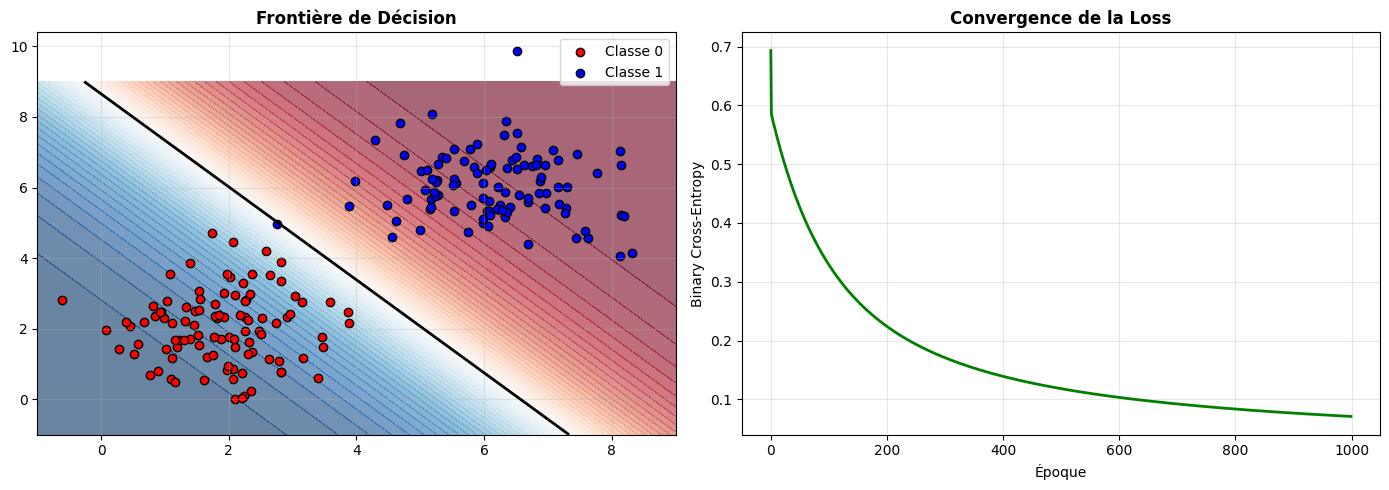

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# JOUR 6 : Régression Logistique from Scratch
# ============================================================

class LogisticRegression:
    """
    Régression logistique : classification binaire avec probabilités.
    C'est un neurone avec sigmoid + cross-entropy loss.
    """

    def __init__(self, n_features, learning_rate=0.1):
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.lr = learning_rate
        self.losses = []

    def sigmoid(self, z):
        """Fonction sigmoid : écrase z entre 0 et 1."""
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def forward(self, X):
        """
        Propagation avant : calcule les probabilités.
        
        Args:
            X: matrice (m, n) — m exemples, n features
        
        Returns:
            Vecteur de probabilités (m,)
        """
        z = X @ self.weights + self.bias  # @ = produit matriciel
        return self.sigmoid(z)

    def compute_loss(self, y_true, y_pred):
        """Calcule la binary cross-entropy loss."""
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    def train(self, X, y, n_epochs=1000, verbose=True):
        """
        Entraîne le modèle par descente de gradient.
        """
        m = len(y)

        for epoch in range(n_epochs):
            # --- Forward pass ---
            y_pred = self.forward(X)

            # --- Calcul de la loss ---
            loss = self.compute_loss(y, y_pred)
            self.losses.append(loss)

            # --- Calcul des gradients ---
            error = y_pred - y
            dw = (1 / m) * (X.T @ error)
            db = (1 / m) * np.sum(error)

            # --- Mise à jour des paramètres ---
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            # --- Affichage ---
            if verbose and (epoch < 5 or epoch % 200 == 0):
                accuracy = np.mean((y_pred >= 0.5) == y)
                print(f"  Époque {epoch+1:>4} : loss = {loss:.4f}, accuracy = {accuracy:.2%}")

    def predict(self, X):
        """Retourne les prédictions (0 ou 1)."""
        return (self.forward(X) >= 0.5).astype(int)

    def predict_proba(self, X):
        """Retourne les probabilités."""
        return self.forward(X)


# --- Créer un dataset synthétique ---
np.random.seed(42)

# Classe 0 : centrée autour de (2, 2)
X0 = np.random.randn(100, 2) + np.array([2, 2])
# Classe 1 : centrée autour de (6, 6)
X1 = np.random.randn(100, 2) + np.array([6, 6])

X = np.vstack([X0, X1])
y = np.hstack([np.zeros(100), np.ones(100)])

# Mélanger les données
shuffle_idx = np.random.permutation(len(y))
X, y = X[shuffle_idx], y[shuffle_idx]

# --- Entraîner ---
print("=== Régression Logistique ===\n")
model = LogisticRegression(n_features=2, learning_rate=0.1)
model.train(X, y, n_epochs=1000)

# --- Résultats ---
predictions = model.predict(X)
accuracy = np.mean(predictions == y)
print(f"\nAccuracy finale : {accuracy:.2%}")

# --- Visualisation ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 : Frontière de décision
xx, yy = np.meshgrid(np.linspace(-1, 9, 200), np.linspace(-1, 9, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
probs = model.predict_proba(grid).reshape(xx.shape)

axes[0].contourf(xx, yy, probs, levels=50, cmap='RdBu_r', alpha=0.6)
axes[0].contour(xx, yy, probs, levels=[0.5], colors='black', linewidths=2)
axes[0].scatter(X[y == 0][:, 0], X[y == 0][:, 1], c='red', label='Classe 0', edgecolors='black')
axes[0].scatter(X[y == 1][:, 0], X[y == 1][:, 1], c='blue', label='Classe 1', edgecolors='black')
axes[0].set_title("Frontière de Décision", fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2 : Courbe de loss
axes[1].plot(model.losses, 'g-', linewidth=2)
axes[1].set_title("Convergence de la Loss", fontweight='bold')
axes[1].set_xlabel("Époque")
axes[1].set_ylabel("Binary Cross-Entropy")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("logistic_regression.png", dpi=150)
plt.show()